In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False
from sklearn.model_selection import train_test_split
df = pd.read_excel('2025-1-14公众号Python机器学习AI.xlsx')
# 划分特征和目标变量
X = df.drop(['y'], axis=1)
y = df['y']
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=42, stratify=df['y'])
                                                    
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score

# 定义 XGBoost 二分类模型
model_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=8)
# eval_metric='logloss' 指定评估指标为 logloss，对数损失是分类问题中常用的评估指标，它衡量的是预测概率与实际标签之间的差异

# 定义参数网格
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 定义 K 折交叉验证 (Stratified K-Fold)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=8)
# 这是分层K折叠，用于解决分类问题中的数据不平衡问题，折叠5次，会让每次都让其中4份做训练集，剩下一份做验证集 
# 验证集的作用是评估模型性能，并选择最佳参数

# 使用网格搜索寻找最佳参数
grid_search = GridSearchCV(estimator=model_xgb, param_grid=param_grid, scoring='accuracy',
                           cv=kfold, verbose=1, n_jobs=1)

# 拟合模型
grid_search.fit(X_train, y_train)
# 使用最优参数训练模型
xgboost = grid_search.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits


训练集 (用于训练模型)  
验证集 (用于调参和模型选择)  
测试集 (用于最终性能评估)  
分层K折交叉验证（Stratified K-Fold Cross Validation）  
分层K折交叉验证是K折交叉验证的一种变体，它确保：  
每个折中各类别的比例与整个数据集中各类别的比例相同  
特别适用于类别不平衡的数据集  
例如，如果原始数据集中正负样本比例为7:3，那么每个折中的正负样本比例也会保持7:3。  

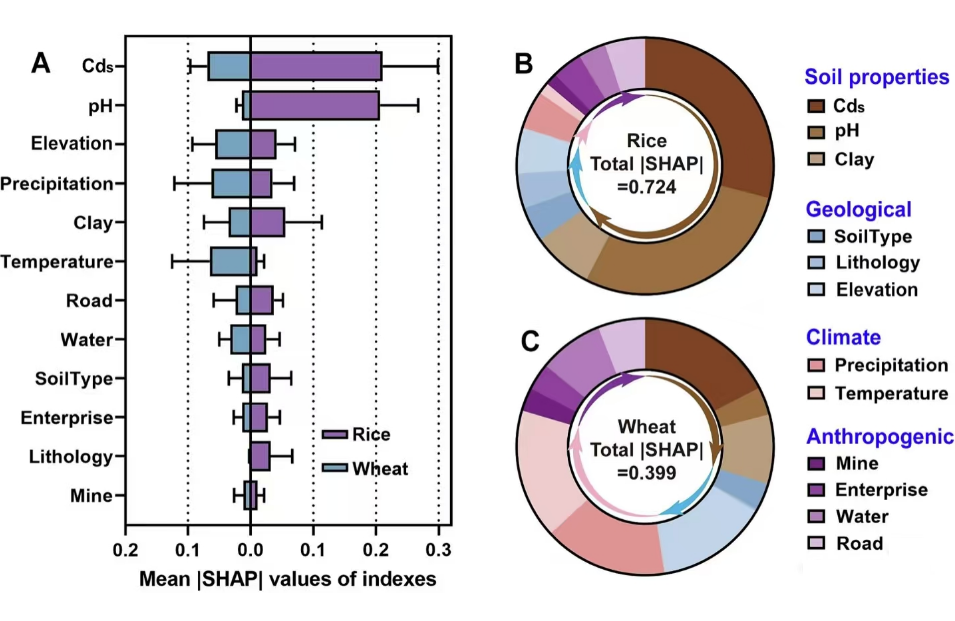

In [2]:
import shap
explainer = shap.TreeExplainer(xgboost)
# 计算shap值为numpy.array数组
shap_values_numpy = explainer.shap_values(X)
shap_values_df = pd.DataFrame(shap_values_numpy, columns=X.columns)
shap_values_df.head()

,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,X_9,X_10,X_11,X_12,X_13
0,0.197101,0.041192,-0.394573,0.021987,-0.042424,0.0,0.008760,0.043932,-0.070200,0.285993,0.057480,-0.329654,-0.114940
1,0.012386,0.108142,0.766380,0.082674,0.094827,0.0,0.029670,0.017007,0.195312,-0.004867,0.069001,0.661767,-0.464300
2,0.007736,0.069104,0.646562,0.015347,-0.045636,0.0,0.013901,0.030495,0.079756,0.409199,0.111587,0.417523,0.554980
3,-0.289680,0.025642,-0.352027,-0.040929,-0.020332,0.0,-0.005962,-0.025490,-0.088519,0.666801,0.042141,-0.331431,-0.611506
4,-0.306688,-0.067160,-0.526901,-0.055780,-0.154773,0.0,0.011106,-0.025699,-0.035873,-0.058778,-0.073882,-0.267132,-0.543921


In [ ]:
shap_values_noabs = shap_values_df
#根据原始数据 df['y'] 分组，计算特征贡献度的非绝对值均值
mean_contributions = shap_values_noabs.groupby(df['y']).mean()
mean_contributions_transposed = mean_contributions.T
mean_contributions_transposed 

y,0,1
X_1,-0.082348,0.071796
X_2,-0.031466,0.013502
X_3,-0.304098,0.347870
X_4,-0.028724,0.037127
X_5,-0.027310,0.018015
X_6,0.000000,0.000000
X_7,-0.002098,0.004055
X_8,-0.010035,0.016282
X_9,-0.031834,0.035525
X_10,-0.085707,0.098046


In [13]:
#计算 SHAP 值的绝对值
shap_values_abs = shap_values_df.abs()
#根据原始数据 df['y'] 分组，计算特征贡献度的绝对值均值
mean_abs_contributions = shap_values_abs.groupby(df['y']).mean()
mean_abs_contributions_transposed = mean_abs_contributions.T
mean_abs_contributions_transposed 

y,0,1
X_1,0.227484,0.149642
X_2,0.070736,0.088696
X_3,0.530653,0.655145
X_4,0.068475,0.068836
X_5,0.104627,0.084353
X_6,0.000000,0.000000
X_7,0.014321,0.021159
X_8,0.030228,0.034233
X_9,0.062912,0.082985
X_10,0.128965,0.193887


这里我们又可能会有疑问了  
为什么在第五格和第六格的代码中两串代码都是先根据y进行分组再计算了分组中得shap得平均值，先分组再进行平均值的操作的话，那这两串代码输出结果应该也就是y = 0的那一列数值相同，但是正负相反，但是最后代码输出的结果是数值也不相同，正负也不相同，这是怎么回事？  
在二分类的机器学习算法中，以X_1变量为例，索引为3的这个样本，shap值输出的结果是负的，则说明在这个样本中，x_1变量是对该样本变成0做出贡献，在索引为0的样本中，x_1变量对样本变成1做出贡献。shap的正一般是和数据中的1的方向是相同的。  
这时候很有可能先入为主认为，如果对样本按照y进行分类，认为y=0的样本中，相同特征变量的方向是一致的，同样认为y=1的样本中，相同特征变量的方向是一致的。但是这是错误的，举个例子，在y=0的样本中，x_1变量可能在某些样本上是正贡献，但是同样是可能存在负贡献，就好比说高血压在年轻群体中对人群健康造成威胁，但是在心衰患者群体中，较高的血压却可以延长患者寿民。  
所以如果一旦认为所有y=0的样本中shap都是负数，y=1的样本中shap都是正数，那我们就当然可以按照第五格中的代码一样直接不算绝对值直接分组。  
但是这样会出现mean([-2, -1, 1, 2]) = 0这种情况，从而抹灭一些样本的贡献。  
所以我们一定要先对shap值取绝对值，再按照绝对值进行分组。  

In [ ]:
# 为 mean_abs_contributions_transposed 添加一列，用于存储每个特征的 mean(|SHAP value|) 均值
mean_abs_contributions_transposed['mean_contribution'] = mean_abs_contributions_transposed.mean(axis=1)

# 根据 'mean_contribution' 列进行降序排序
sorted_contributions = mean_abs_contributions_transposed.sort_values(by='mean_contribution', ascending=True)
# ascending=True 表示升序排序，即从小到大
# 删除排序辅助列，保留排序后的结果
sorted_contributions = sorted_contributions.drop(columns=['mean_contribution'])

# 查看排序后的结果
sorted_contributions

y,0,1
X_6,0.000000,0.000000
X_7,0.014321,0.021159
X_8,0.030228,0.034233
X_4,0.068475,0.068836
X_9,0.062912,0.082985
X_11,0.068160,0.089856
X_2,0.070736,0.088696
X_5,0.104627,0.084353
X_10,0.128965,0.193887
X_1,0.227484,0.149642


In [ ]:
# 准备数据
features = sorted_contributions.index  # 特征名
class_0_values = sorted_contributions[0]  # 类别 0 的均值
class_1_values = sorted_contributions[1]  # 类别 1 的均值

# 计算误差线的上下限
error_0 = shap_values_abs[df['y'] == 0].std()  # 类别 0 的标准差作为误差
error_1 = shap_values_abs[df['y'] == 1].std()  # 类别 1 的标准差作为误差

# 开始绘制
fig, ax = plt.subplots(figsize=(6, 10), dpi=1200)

# 绘制类别 0（左侧，蓝色），通过负方向偏移实现显示在左侧，同时数值为正
ax.barh(features, -class_0_values, color="skyblue", edgecolor="black", label="Survival")
ax.errorbar(-class_0_values, features, xerr=[error_0, np.zeros_like(error_0)],  # 左侧误差线
            fmt="none", ecolor="black", capsize=4, elinewidth=1.2)

# 绘制类别 1（右侧，紫色），保持右侧正值
ax.barh(features, class_1_values, color="purple", edgecolor="black", label="Death")
ax.errorbar(class_1_values, features, xerr=[np.zeros_like(error_1), error_1],  # 右侧误差线
            fmt="none", ecolor="black", capsize=4, elinewidth=1.2)
# features：误差线的y轴位置（对应特征名称
# 添加竖线：x=0 用实线
ax.axvline(0, color="black", linewidth=1.2, linestyle="-")  # x=0 中心实线

# 自定义 x 轴刻度，将类别 0 的区域映射为正值
x_ticks = np.arange(0, 1.1, 0.5)  # 自定义刻度范围（正值）
x_ticks_negative = -x_ticks[1:]  # 创建左侧对称刻度（负值跳过0）
ax.set_xticks(np.concatenate([x_ticks_negative, x_ticks]))  # 合并正负刻度
ax.set_xticklabels([str(abs(x)) for x in np.concatenate([x_ticks_negative, x_ticks])])  # 设置标签为正值

# 灰色虚线优化，左侧和右侧对称
for x in x_ticks:
    if x != 0:
        ax.axvline(-x, color="#696969", linewidth=0.8, linestyle="--", zorder=0)  # 左侧灰色虚线
        ax.axvline(x, color="#696969", linewidth=0.8, linestyle="--", zorder=0)  # 右侧灰色虚线

# 字体整体加粗
ax.set_xlabel("Mean |SHAP| values of indexes", fontsize=14, fontweight='bold')  # x轴标签加粗
ax.set_ylabel("Features", fontsize=14, fontweight='bold')  # y轴标签加粗
ax.set_title("Feature Contributions by Class", fontsize=16, fontweight='bold')  # 标题加粗

# 设置图例字体加粗
ax.legend(loc="lower right", fontsize=12, frameon=False, prop={'weight': 'bold'})  # 图例右下角，无边框，加粗

# 设置 x 和 y 轴刻度字体加粗
ax.tick_params(axis='both', which='major', labelsize=12, width=1.2, length=6)  # 刻度线加粗

# 设置 x 轴范围
ax.set_xlim(-1.5, 1.5)  # 根据数据调整范围

# 保证布局紧凑
plt.tight_layout()
plt.savefig('1.png', format='png', bbox_inches='tight')
plt.show()